# Core 02 — Logistic Regression (Medical Risk)

Industrial classification: calibration, thresholding, PR/ROC, error analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score)
np.random.seed(7); sns.set_theme(style='whitegrid')


## 1) Cohort synthesis

In [2]:
n=4000
age=np.clip(np.random.normal(52, 14, n), 18, 90)
bmi=np.clip(np.random.normal(27, 5.2, n), 16, 55)
sbp=np.clip(np.random.normal(130, 17, n), 90, 215)
chol=np.clip(np.random.normal(5.2, 1.1, n), 2.5, 10.0)
smoker=np.random.binomial(1, 0.28, n)
diab=np.random.binomial(1, 0.12, n)
activity=np.clip(np.random.normal(3.0, 1.1, n), 0, 7)
logit=(-7.1+0.033*age+0.075*(bmi-25)+0.018*(sbp-120)+0.5*smoker+0.95*diab-0.22*activity+0.012*(chol-5.0)*(sbp-120)/10.0)
p=1/(1+np.exp(-logit))
y=np.random.binomial(1,p)
df=pd.DataFrame({'age':age,'bmi':bmi,'sbp':sbp,'chol':chol,'smoker':smoker,'diabetic':diab,'activity':activity,'risk':y})
df['risk'].mean(), df.head()


(0.00375,
          age        bmi         sbp      chol  smoker  diabetic  activity  \
 0  75.667360  29.162390  130.056901  3.312001       1         0  2.302254   
 1  45.476877  25.622028  111.566834  5.719723       0         0  4.387888   
 2  52.459482  19.108983  120.113128  4.889485       0         0  3.175703   
 3  57.705228  32.598845  134.188716  5.412943       0         0  3.346291   
 4  40.955078  30.242598  148.285723  5.444347       0         0  3.067822   
 
    risk  
 0     0  
 1     0  
 2     0  
 3     0  
 4     0  )

## 2) Train/test + model

In [3]:
X=df.drop(columns=['risk']); y=df['risk']
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)
pipe=Pipeline([('scaler',StandardScaler()),('clf',LogisticRegression(max_iter=3000,class_weight='balanced'))])
pipe.fit(Xtr,ytr)
proba=pipe.predict_proba(Xte)[:,1]
pred=(proba>=0.5).astype(int)
auc=roc_auc_score(yte,proba); ap=average_precision_score(yte,proba)
pd.DataFrame({'ROC_AUC':[auc],'PR_AUC':[ap]})


,ROC_AUC,PR_AUC
0,0.441014,0.004471


## 3) Confusion + report

In [4]:
confusion_matrix(yte,pred)

array([[660, 336],
       [  3,   1]], dtype=int64)

In [5]:
print(classification_report(yte,pred, digits=3))

              precision    recall  f1-score   support

           0      0.995     0.663     0.796       996
           1      0.003     0.250     0.006         4

    accuracy                          0.661      1000
   macro avg      0.499     0.456     0.401      1000
weighted avg      0.992     0.661     0.793      1000



## 4) ROC / PR

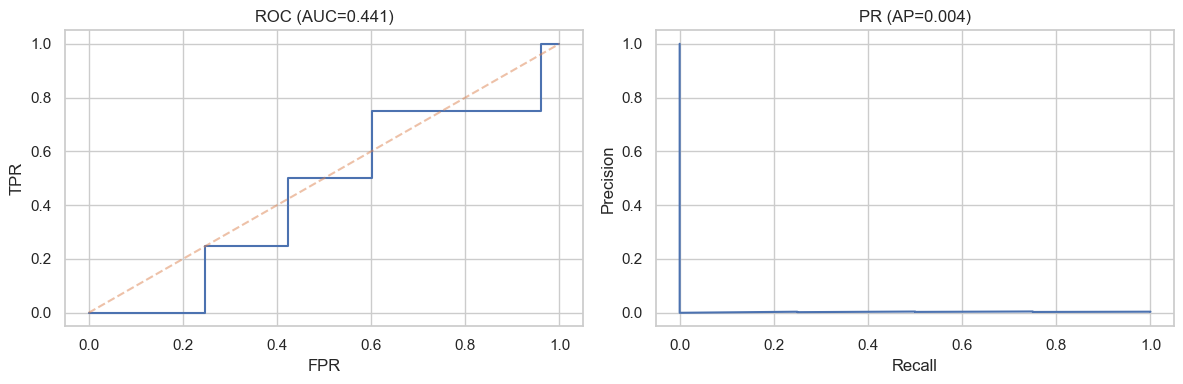

In [6]:
fpr,tpr,_=roc_curve(yte,proba)
prec,rec,_=precision_recall_curve(yte,proba)
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(fpr,tpr); ax[0].plot([0,1],[0,1],'--',alpha=0.5); ax[0].set_title(f'ROC (AUC={auc:.3f})'); ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR')
ax[1].plot(rec,prec); ax[1].set_title(f'PR (AP={ap:.3f})'); ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
plt.tight_layout(); plt.show()


## 5) Threshold tuning (cost-aware)

In [7]:
cost_fn=12; cost_fp=1
ths=np.linspace(0.05,0.95,91)
best=None
for th in ths:
    p=(proba>=th).astype(int)
    tn,fp,fn,tp=confusion_matrix(yte,p).ravel()
    cost=cost_fn*fn + cost_fp*fp
    if best is None or cost<best[0]:
        best=(cost,th,tn,fp,fn,tp)
best


(49, 0.94, 995, 1, 4, 0)

## Conclusion
Notebook complet: modèle, courbes, analyse d'erreur et seuil opérationnel.